In [ ]:
import zarr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

import os
import sys

sys.path.append(os.path.abspath(".."))

from src import orderparameter as op

plt.style.use('../../my_style.mplstyle')

/Users/sasakinozomu/code/MTCargoSim/venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sasakinozomu/code/MTCargoSim/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/sasakinozomu/code/MTCargoSim/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/sasakinozomu/code/MTCargoSim/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/sasakinozomu/code/MTCargoSim/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


TypeError: object of type 'numpy.float64' has no len()

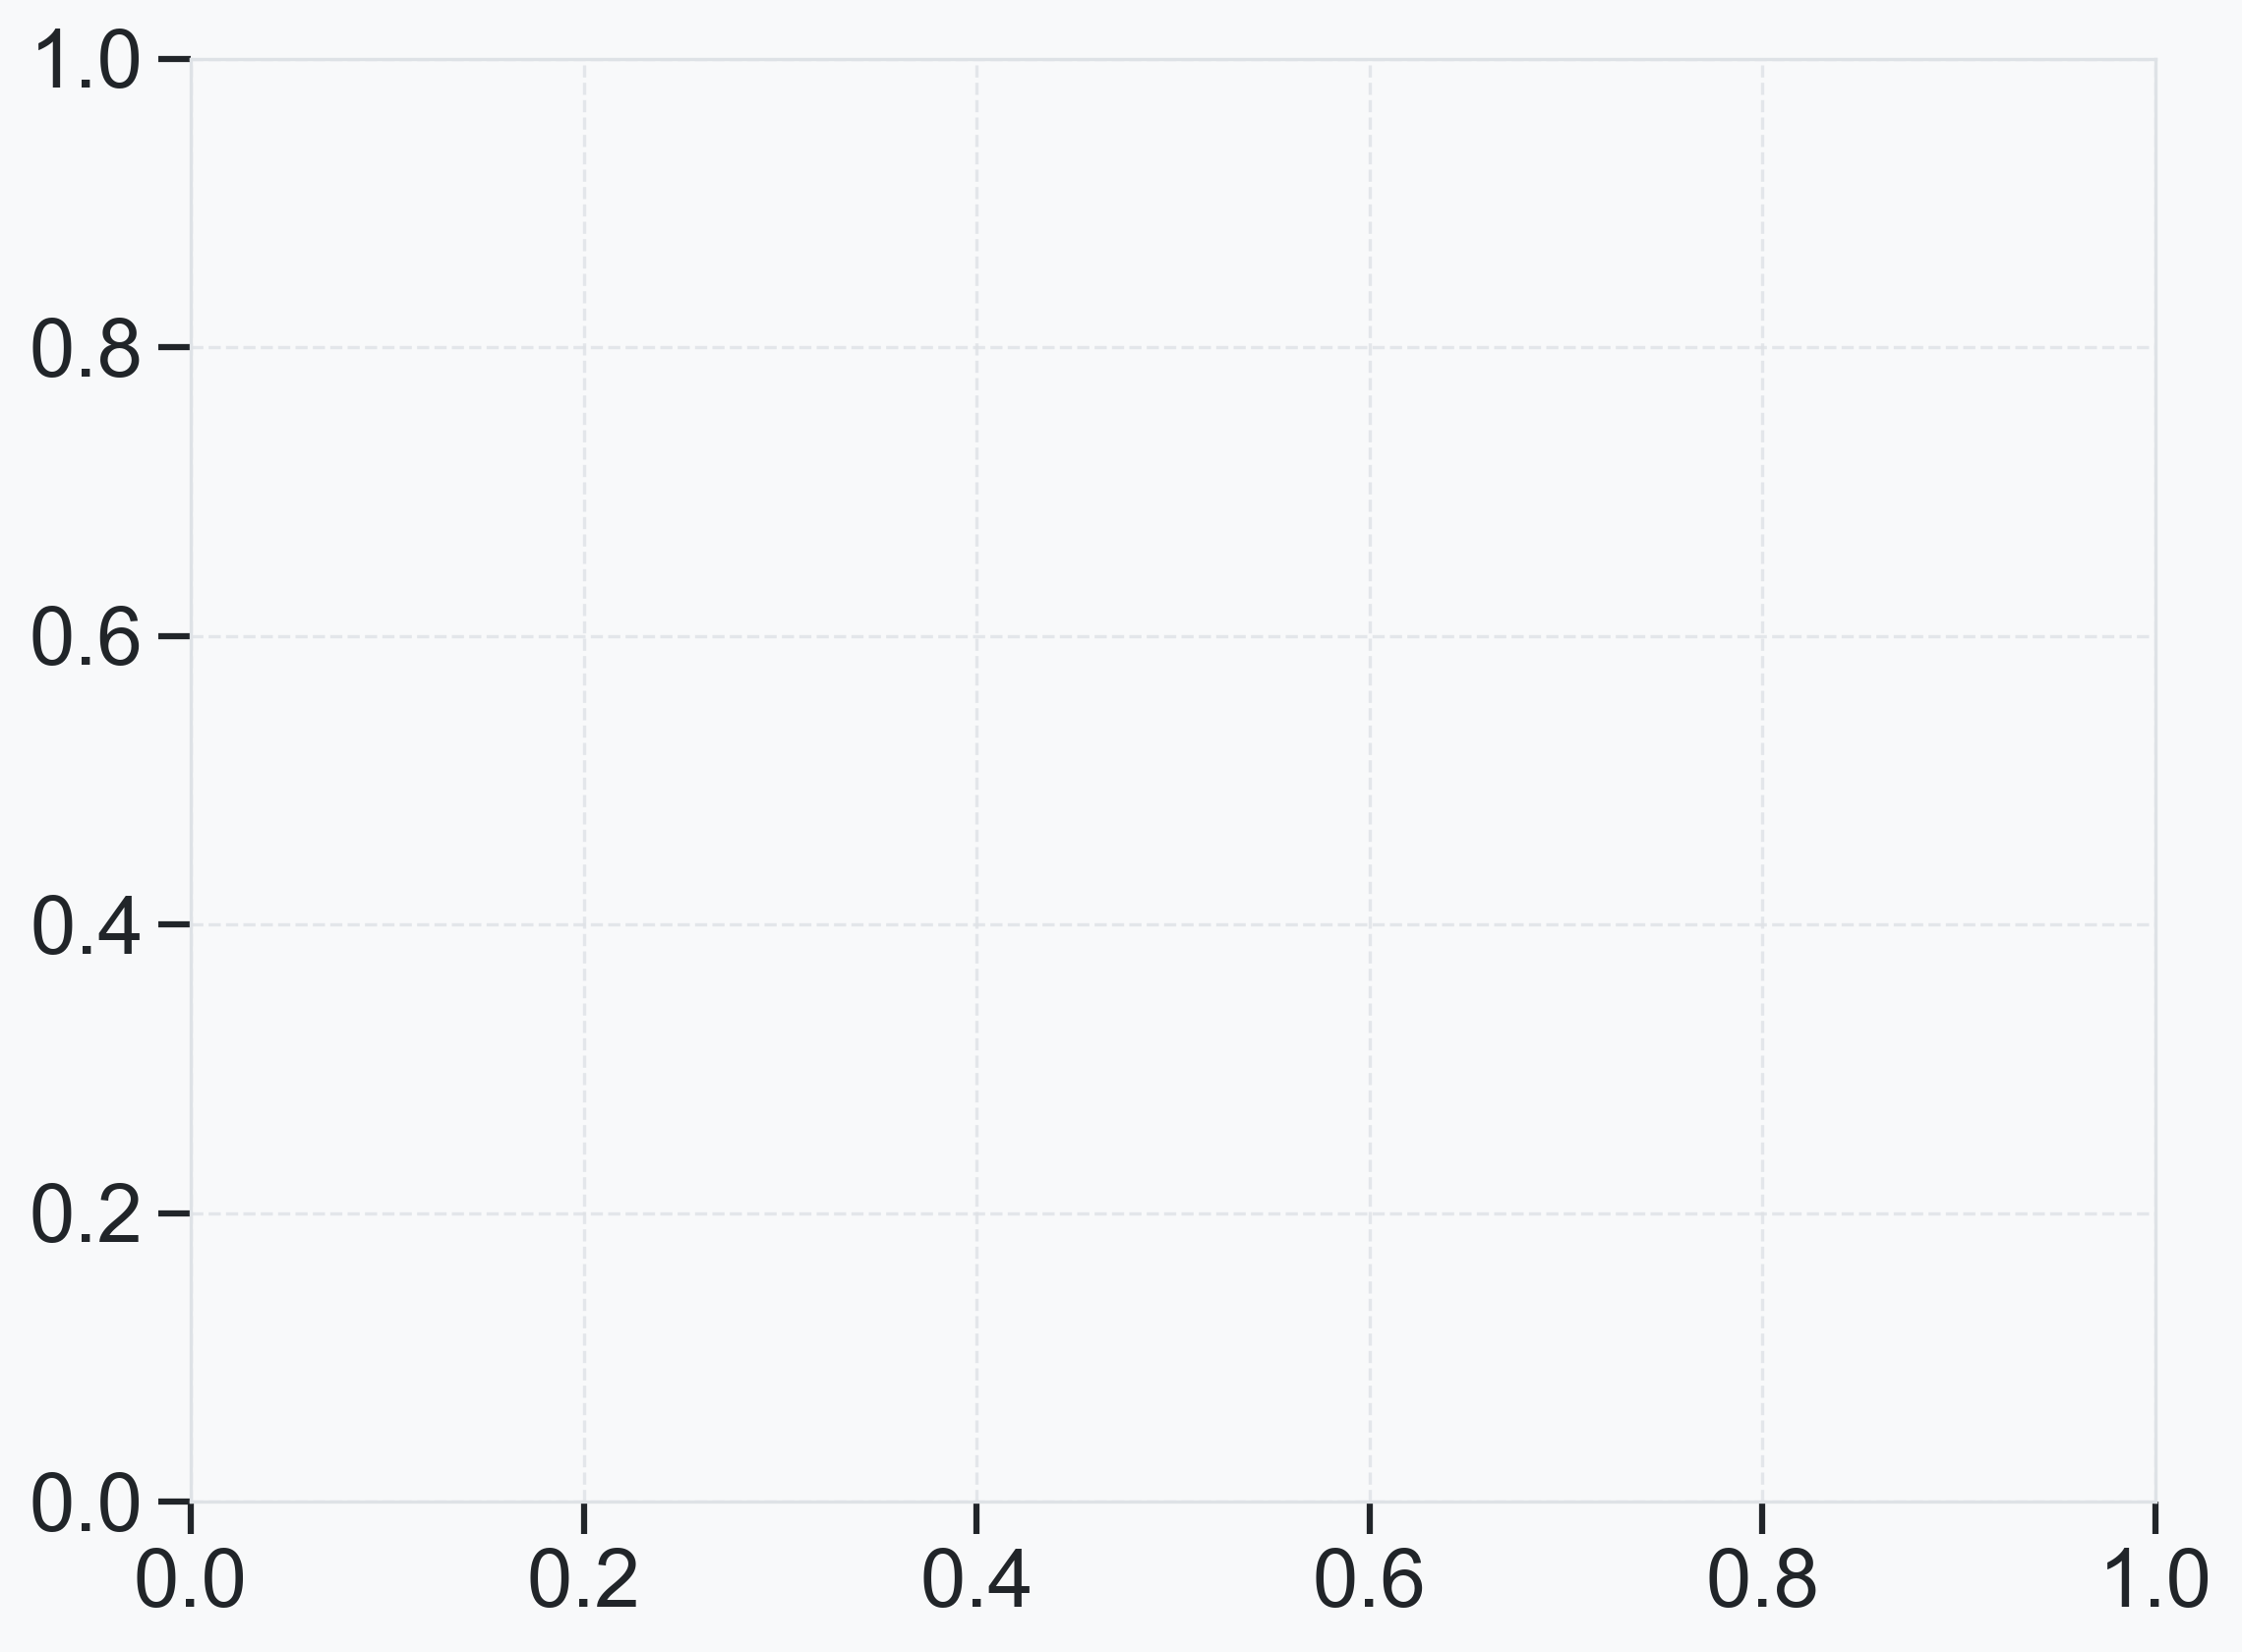

In [ ]:
folder = '/Volumes/My Passport/Sasaki/MTCargoSim/MT/P0.5_A0.1'

S_mean = []
S_std = []

for A in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    folder = f'/Volumes/My Passport/Sasaki/MTCargoSim/MT/P0.5_A{A:.1f}'
    S = op.ensembleS(folder)
    S_mean.append(np.mean(S, axis=0))
    S_std.append(np.std(S, axis=0))


fig, ax = plt.subplots()

"""
ax.plot(S_exp[0, :], S_exp[1, :], label='Experiment 1', linestyle=None, marker='o')
ax.plot(S_exp2[0, :], S_exp2[1, :], label='Experiment 2', linestyle=None, marker='o')
ax.plot(S_exp3[0, :], S_exp3[1, :], label='Experiment 3', linestyle=None, marker='o')
"""
for i in range(len(S_mean)):
    ax.plot(np.arange(len(S_mean[i])), S_mean[i], label=f'A={i*0.1:.1f}', color=plt.cm.viridis(i/9))
    ax.fill_between(np.arange(len(S_mean[i])), S_mean[i] - S_std[i], S_mean[i] + S_std[i], alpha=0.3, color=plt.cm.viridis(i/9))

ax.set(xlabel='Time step $\hat{t}$', ylabel='Order parameter S', xlim = (0, 200))

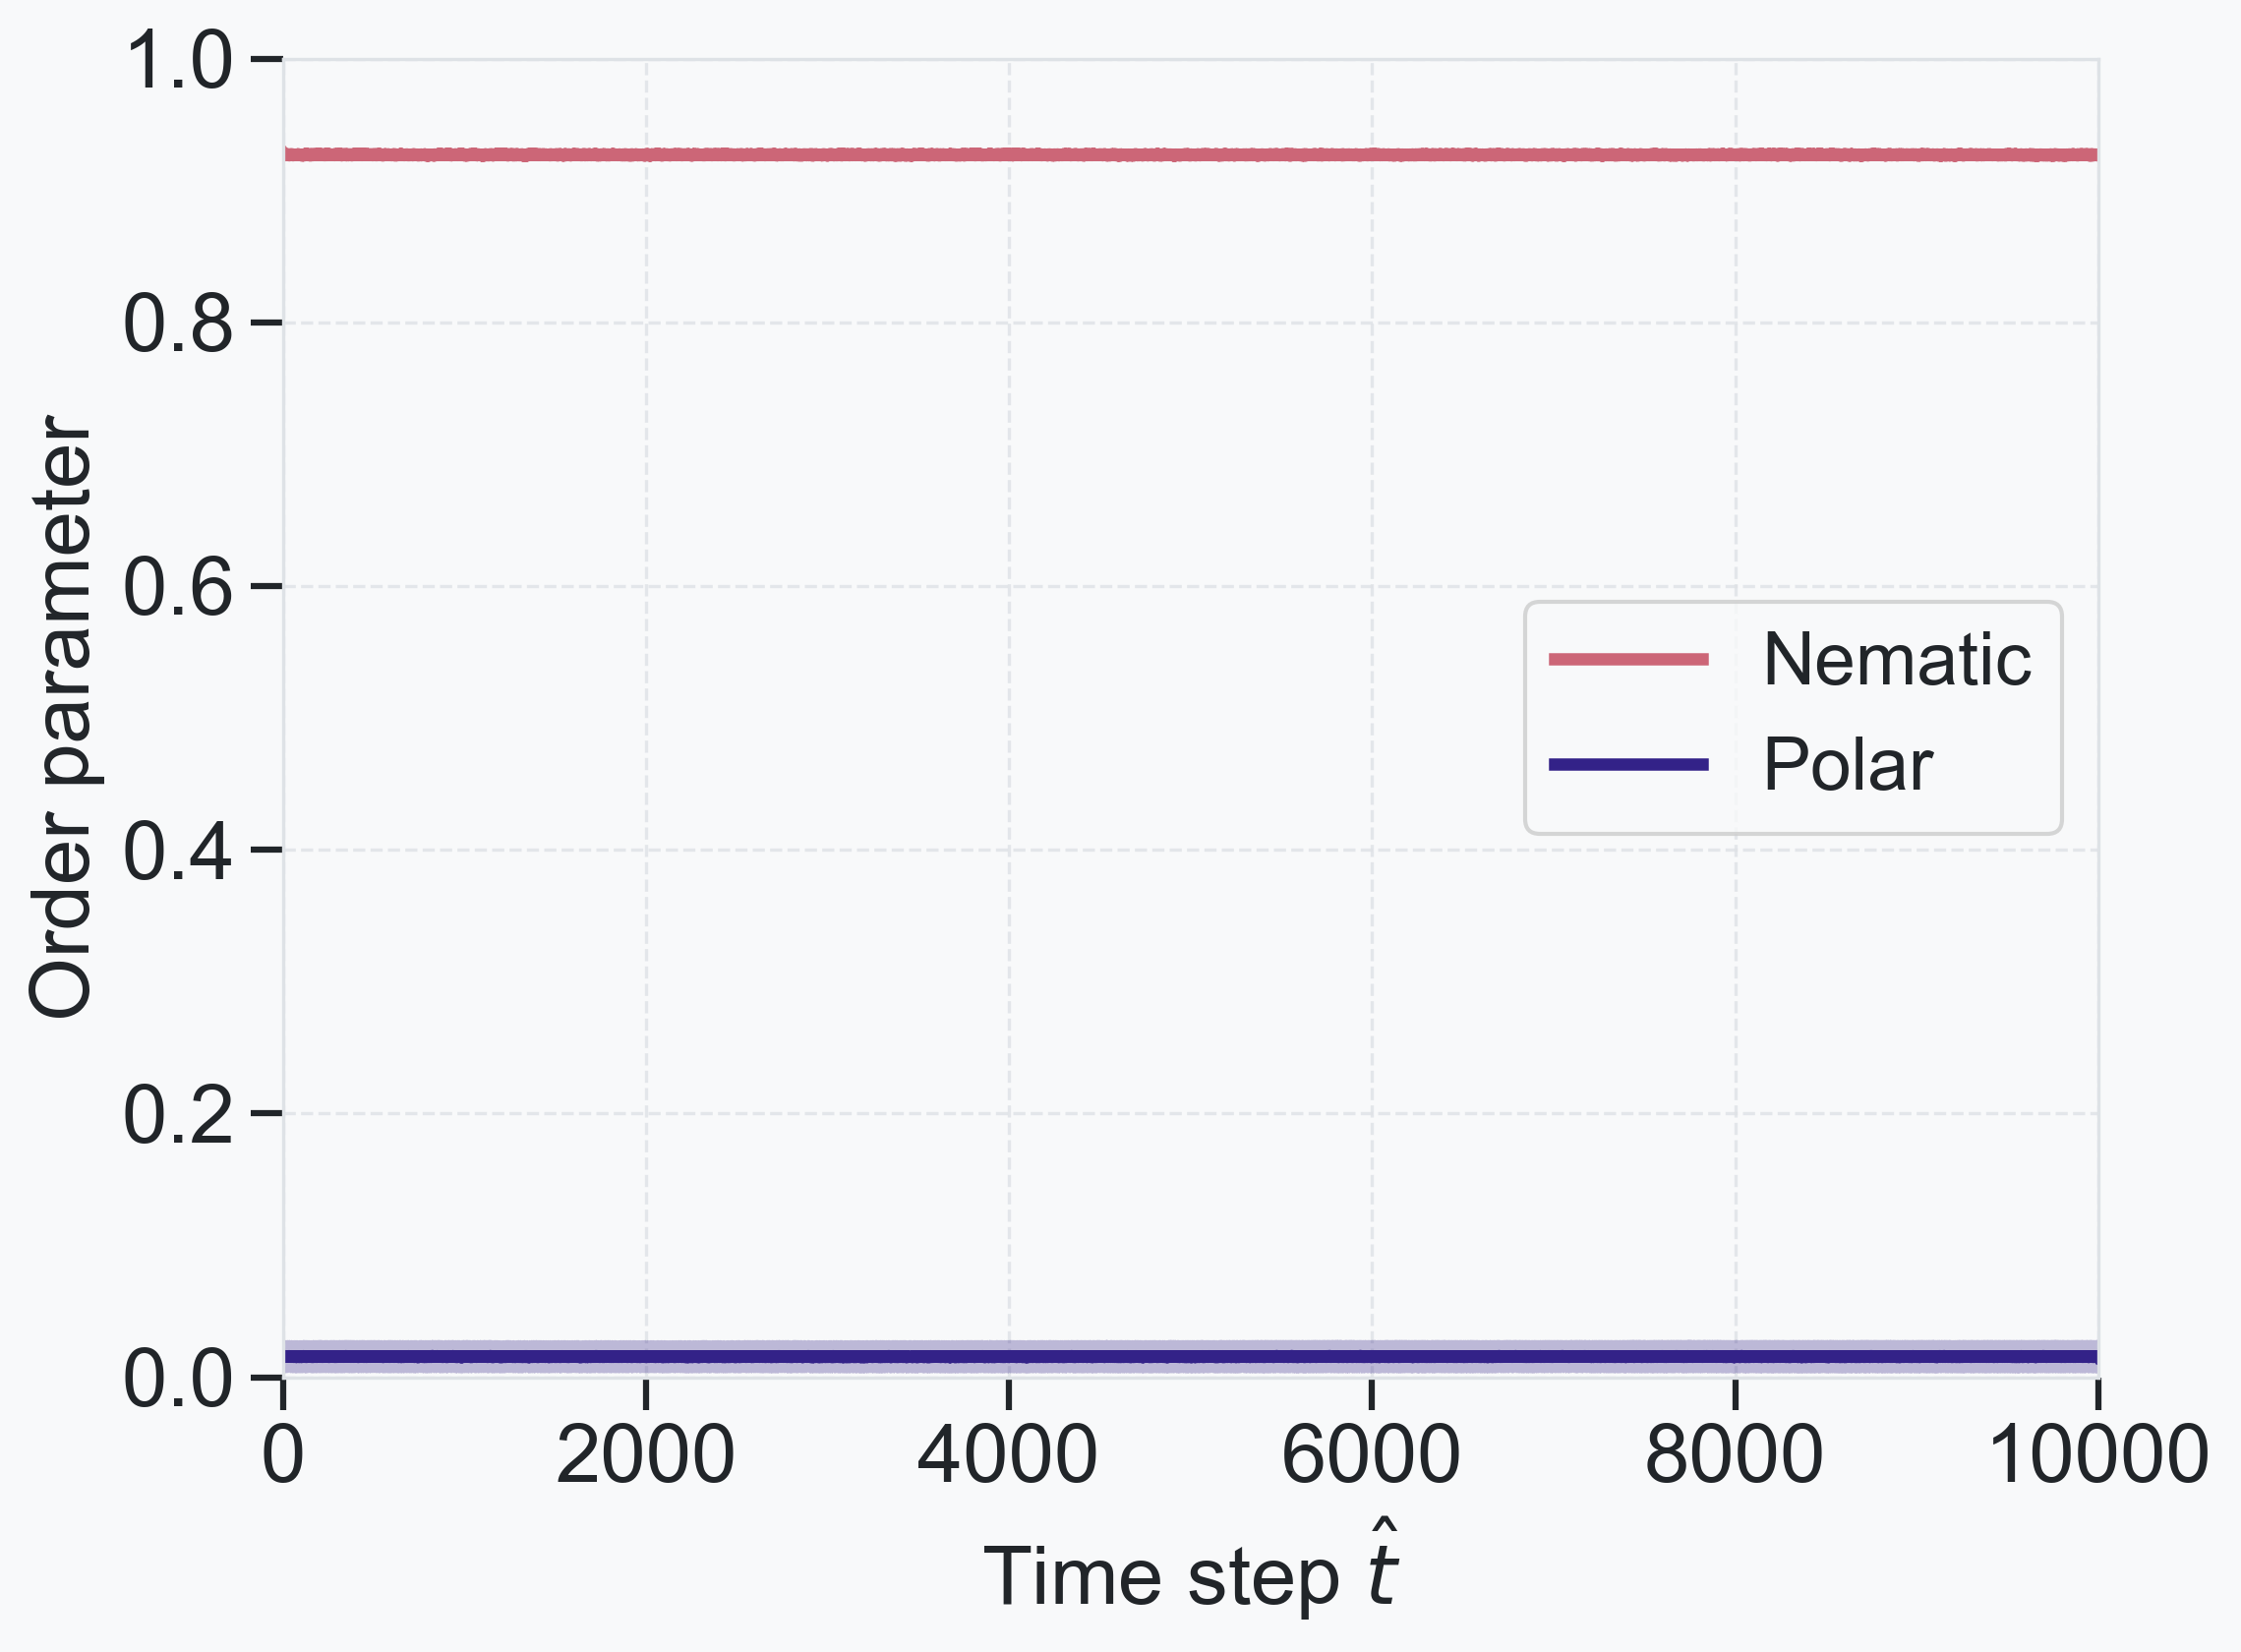

In [8]:
folder = f'/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5'
S = op.ensembleS(folder)
P = op.ensembleP(folder)

fig, ax = plt.subplots()

ax.plot(np.arange(S.shape[1]), np.mean(S, axis=0), label = 'Nematic')
ax.fill_between(np.arange(S.shape[1]), np.mean(S, axis=0) - np.std(S, axis=0), np.mean(S, axis=0) + np.std(S, axis=0), alpha=0.3)

ax.plot(np.arange(P.shape[1]), np.mean(P, axis=0), label='Polar')
ax.fill_between(np.arange(P.shape[1]), np.mean(P, axis=0) - np.std(P, axis=0), np.mean(P, axis=0) + np.std(P, axis=0), alpha=0.3)

ax.set(xlabel='Time step $\hat{t}$', ylabel='Order parameter', xlim = (0, 1e4), ylim = (0, 1))
ax.legend()

#fig.savefig("analysis/data")

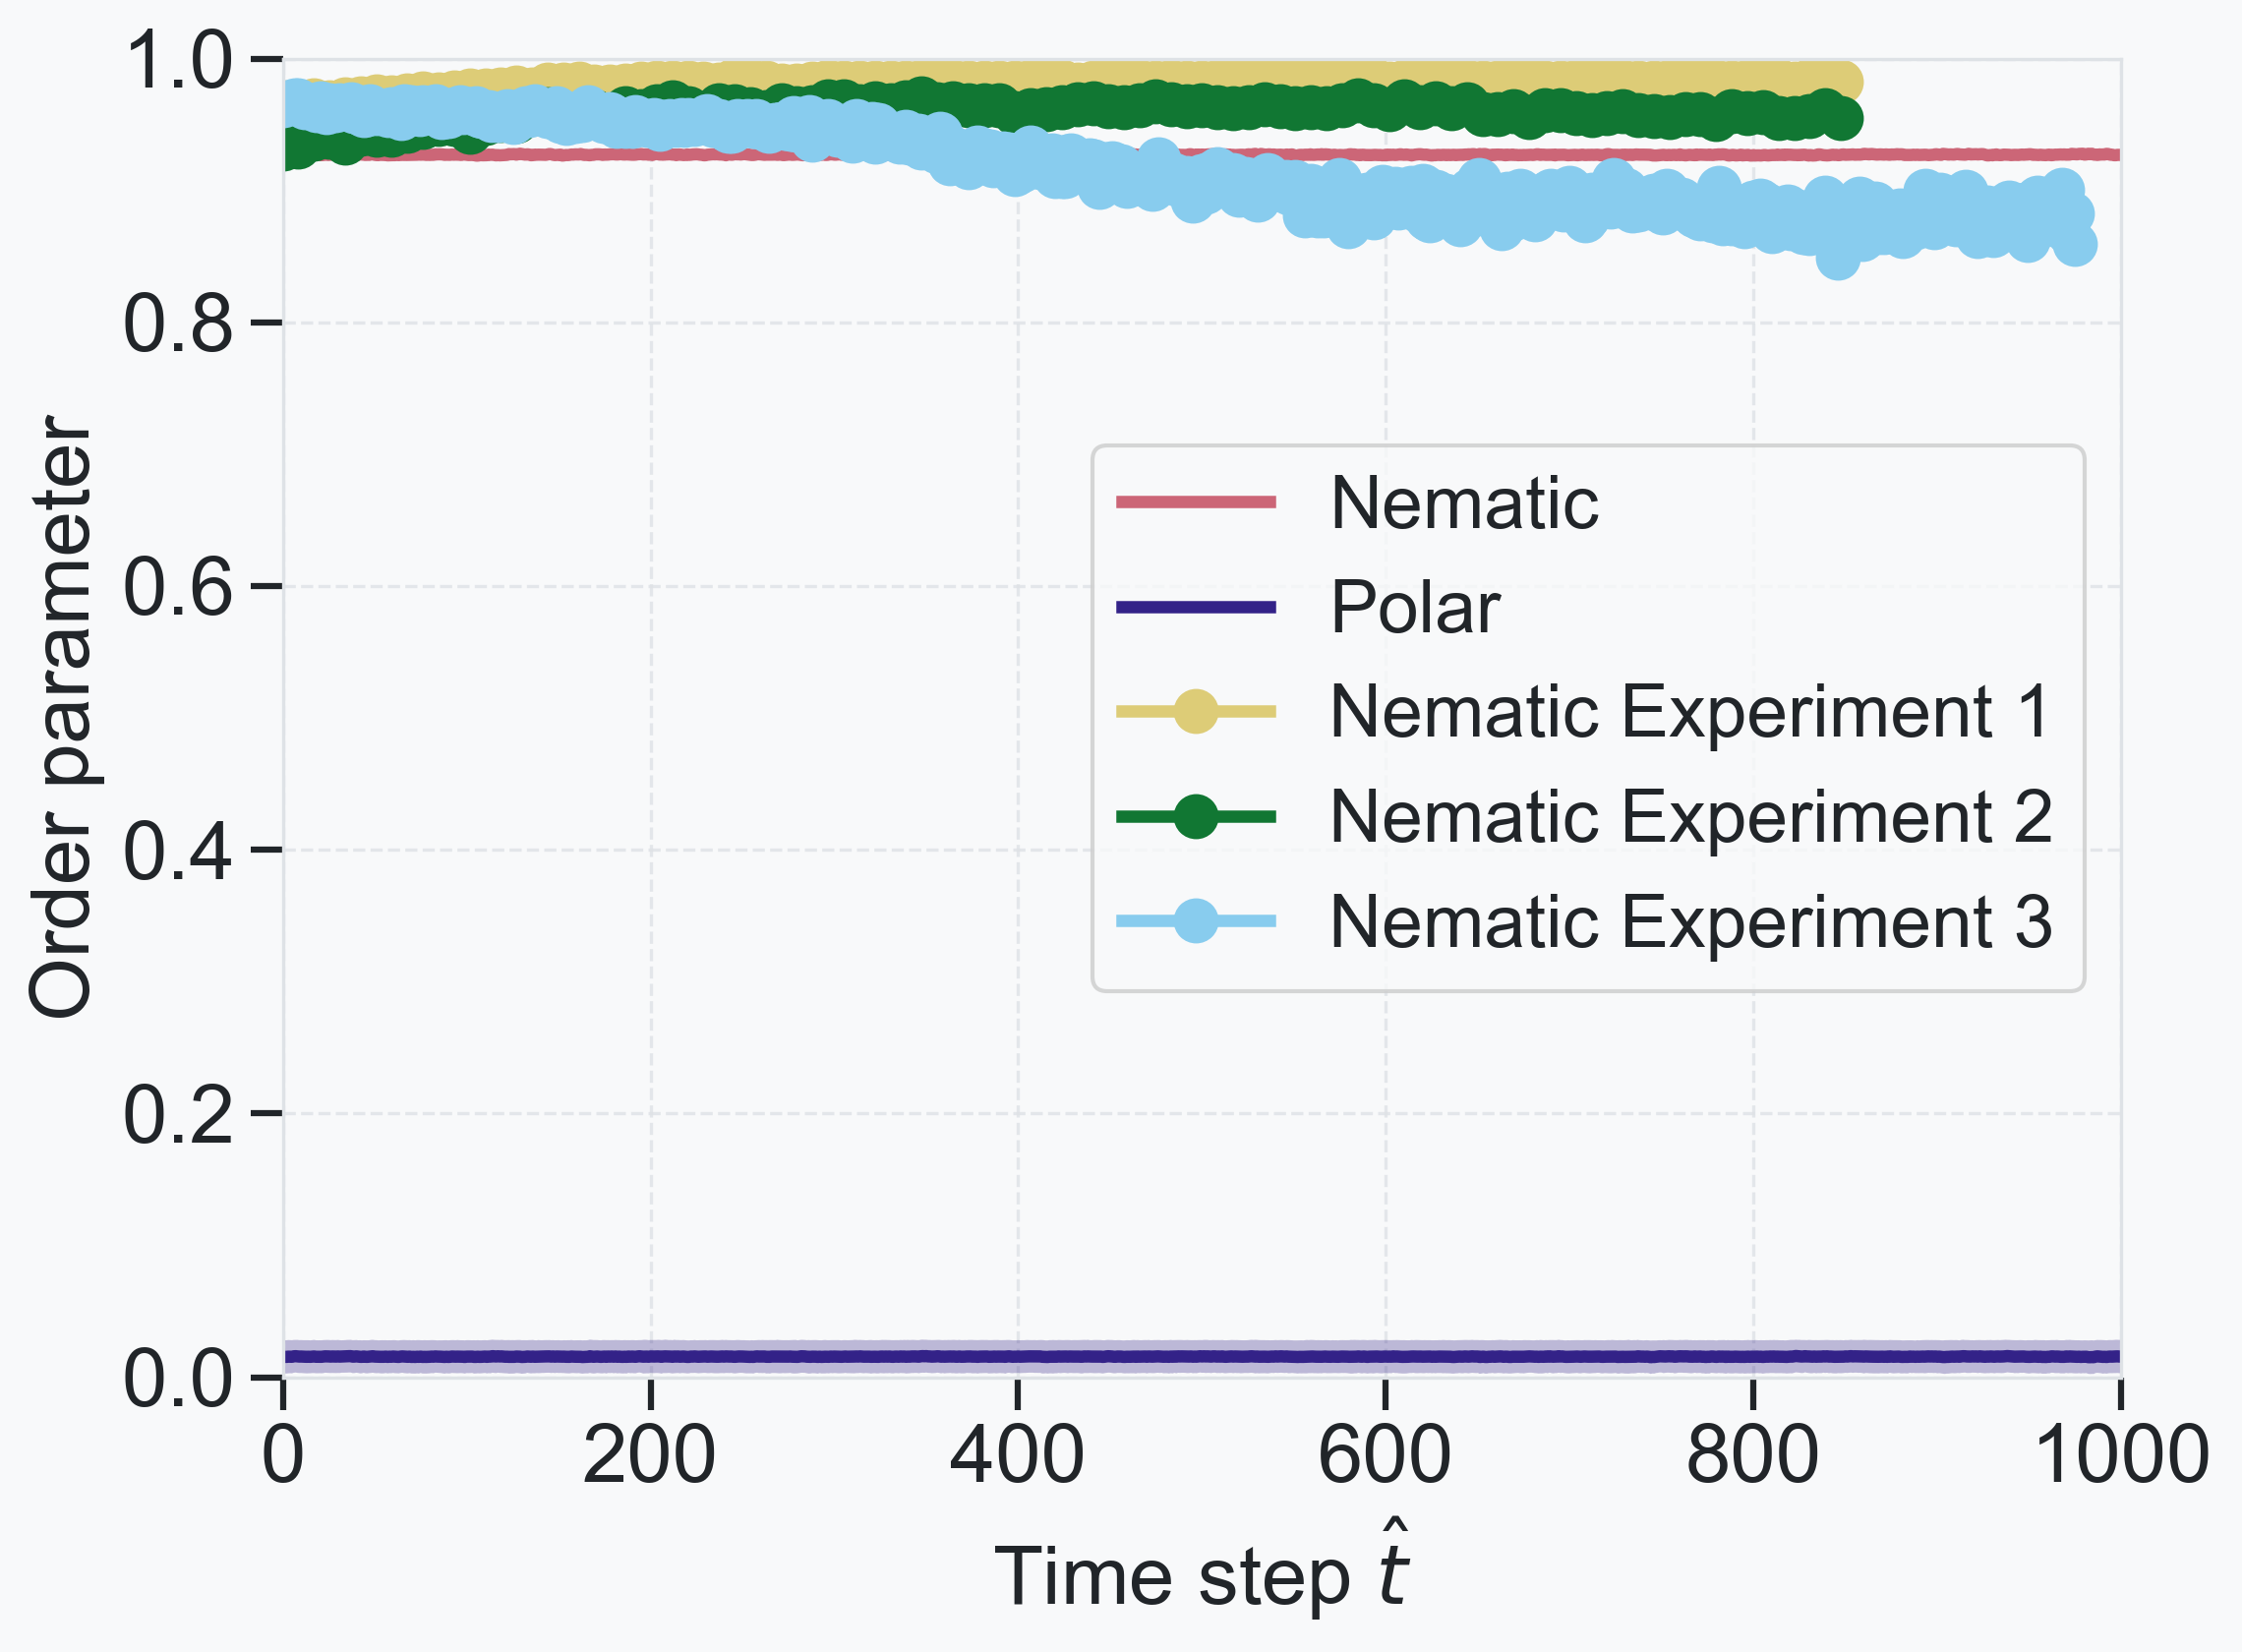

In [16]:
path = '/Volumes/My Passport/Sasaki/MTsingleBeads/20241114/T2_4uM_mc03_zarr/order_parameter.zarr'
path2 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20241114/T2_4uM_mc03_beads_zarr/order_parameter.zarr'
path3 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260107/MTs_order_parameter.zarr'

tau = 1.18

data = zarr.open_array(path, mode='r')
S_exp = data[:]
data2 = zarr.open_array(path2, mode='r')
S_exp2 = data2[:]
data3 = zarr.open_array(path3, mode='r')
S_exp3 = data3[:]
fig, ax = plt.subplots()

ax.plot(np.arange(S.shape[1]), np.mean(S, axis=0), label = 'Nematic')
ax.fill_between(np.arange(S.shape[1]), np.mean(S, axis=0) - np.std(S, axis=0), np.mean(S, axis=0) + np.std(S, axis=0), alpha=0.3)

ax.plot(np.arange(P.shape[1]), np.mean(P, axis=0), label='Polar')
ax.fill_between(np.arange(P.shape[1]), np.mean(P, axis=0) - np.std(P, axis=0), np.mean(P, axis=0) + np.std(P, axis=0), alpha=0.3)

ax.plot(S_exp[0, :]/tau, S_exp[1, :], label='Nematic Experiment 1', linestyle=None, marker='o')
ax.plot(S_exp2[0, :]/tau, S_exp2[1, :], label='Nematic Experiment 2', linestyle=None, marker='o')
ax.plot(S_exp3[0, :]/tau, S_exp3[1, :], label='Nematic Experiment 3', linestyle=None, marker='o')

ax.set(xlabel='Time step $\hat{t}$', ylabel='Order parameter', xlim = (0, 1e3), ylim = (0, 1))
ax.legend()
